# Final evaluation

### 01. Import libraries

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### 02. Configurations

In [18]:
TEST_DIR = Path('../dataset/test')
MODEL_PATH = Path('../models/best_convnext_tiny_hyperparameter_tuned.pth')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 46
IMAGE_SIZE = 224
BATCH_SIZE = 32

### 03. Test transformations, dataset and dataloader

In [12]:
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

### 04. Load ConvNeXt Tiny model

In [13]:
model = models.convnext_tiny(weights=None)
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)
model = model.to(DEVICE)

### 05. Load best hyperparameter-tuned model

In [14]:
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint)
model.eval()
print(f'Best hyperparameter-tuned model loaded successfully: {MODEL_PATH}')

Best hyperparameter-tuned model loaded successfully: ..\models\best_convnext_tiny_hyperparameter_tuned.pth


### 06. Predictions on test dataset

In [15]:
all_labels = []
all_predictions = []
all_probabilities = []

model.eval()

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)
        confidence, predictions = torch.max(probabilities, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(confidence.cpu().numpy())


all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

print(f'[Predictions completed] | Number of predictions: {len(all_predictions)}')

100%|██████████| 223/223 [11:12<00:00,  3.01s/it]

[Predictions completed] | Number of predictions: 7123


### 07. Test accuracy

In [16]:
test_accuracy = accuracy_score(all_labels, all_predictions)

print(f'Test accuracy: {test_accuracy}')
print(f'Test accuracy: {test_accuracy * 100:.2f}%')

Test accuracy: 0.8605924470026675
Test accuracy: 86.06%


### 08. Classification report

In [19]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=test_dataset.classes,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report)
report_df

,Agaricus arvensis,Agaricus augustus,Agaricus campestris,Agaricus xanthodermus,Amanita caesarea,Amanita citrina,Amanita excelsa,Amanita muscaria,Amanita pantherina,Amanita phalloides,...,Russula ochroleuca,Russula vesca,Suillellus luridus,Suillus luteus,Trametes versicolor,Tylopilus felleus,Xerocomellus chrysenteron,accuracy,macro avg,weighted avg
precision,0.515528,0.875000,0.676136,0.711409,0.947059,0.886525,0.846591,0.925926,0.796875,0.881988,...,0.825641,0.769663,0.904192,0.896341,0.972826,0.864198,0.898810,0.860592,0.864247,0.861720
recall,0.509202,0.864198,0.716867,0.692810,0.920000,0.838926,0.823204,0.925926,0.884393,0.855422,...,0.925287,0.815476,0.915152,0.954545,0.978142,0.897436,0.915152,0.860592,0.862691,0.860592
f1-score,0.512346,0.869565,0.695906,0.701987,0.933333,0.862069,0.834734,0.925926,0.838356,0.868502,...,0.872629,0.791908,0.909639,0.924528,0.975477,0.880503,0.906907,0.860592,0.862848,0.860525
support,163.000000,162.000000,166.000000,153.000000,175.000000,149.000000,181.000000,162.000000,173.000000,166.000000,...,174.000000,168.000000,165.000000,154.000000,183.000000,156.000000,165.000000,0.860592,7123.000000,7123.000000


In [21]:
report_df.to_csv('../results/classification_report_hyperparameter_tuned.csv', index=True)

### 09. Confusion matrix

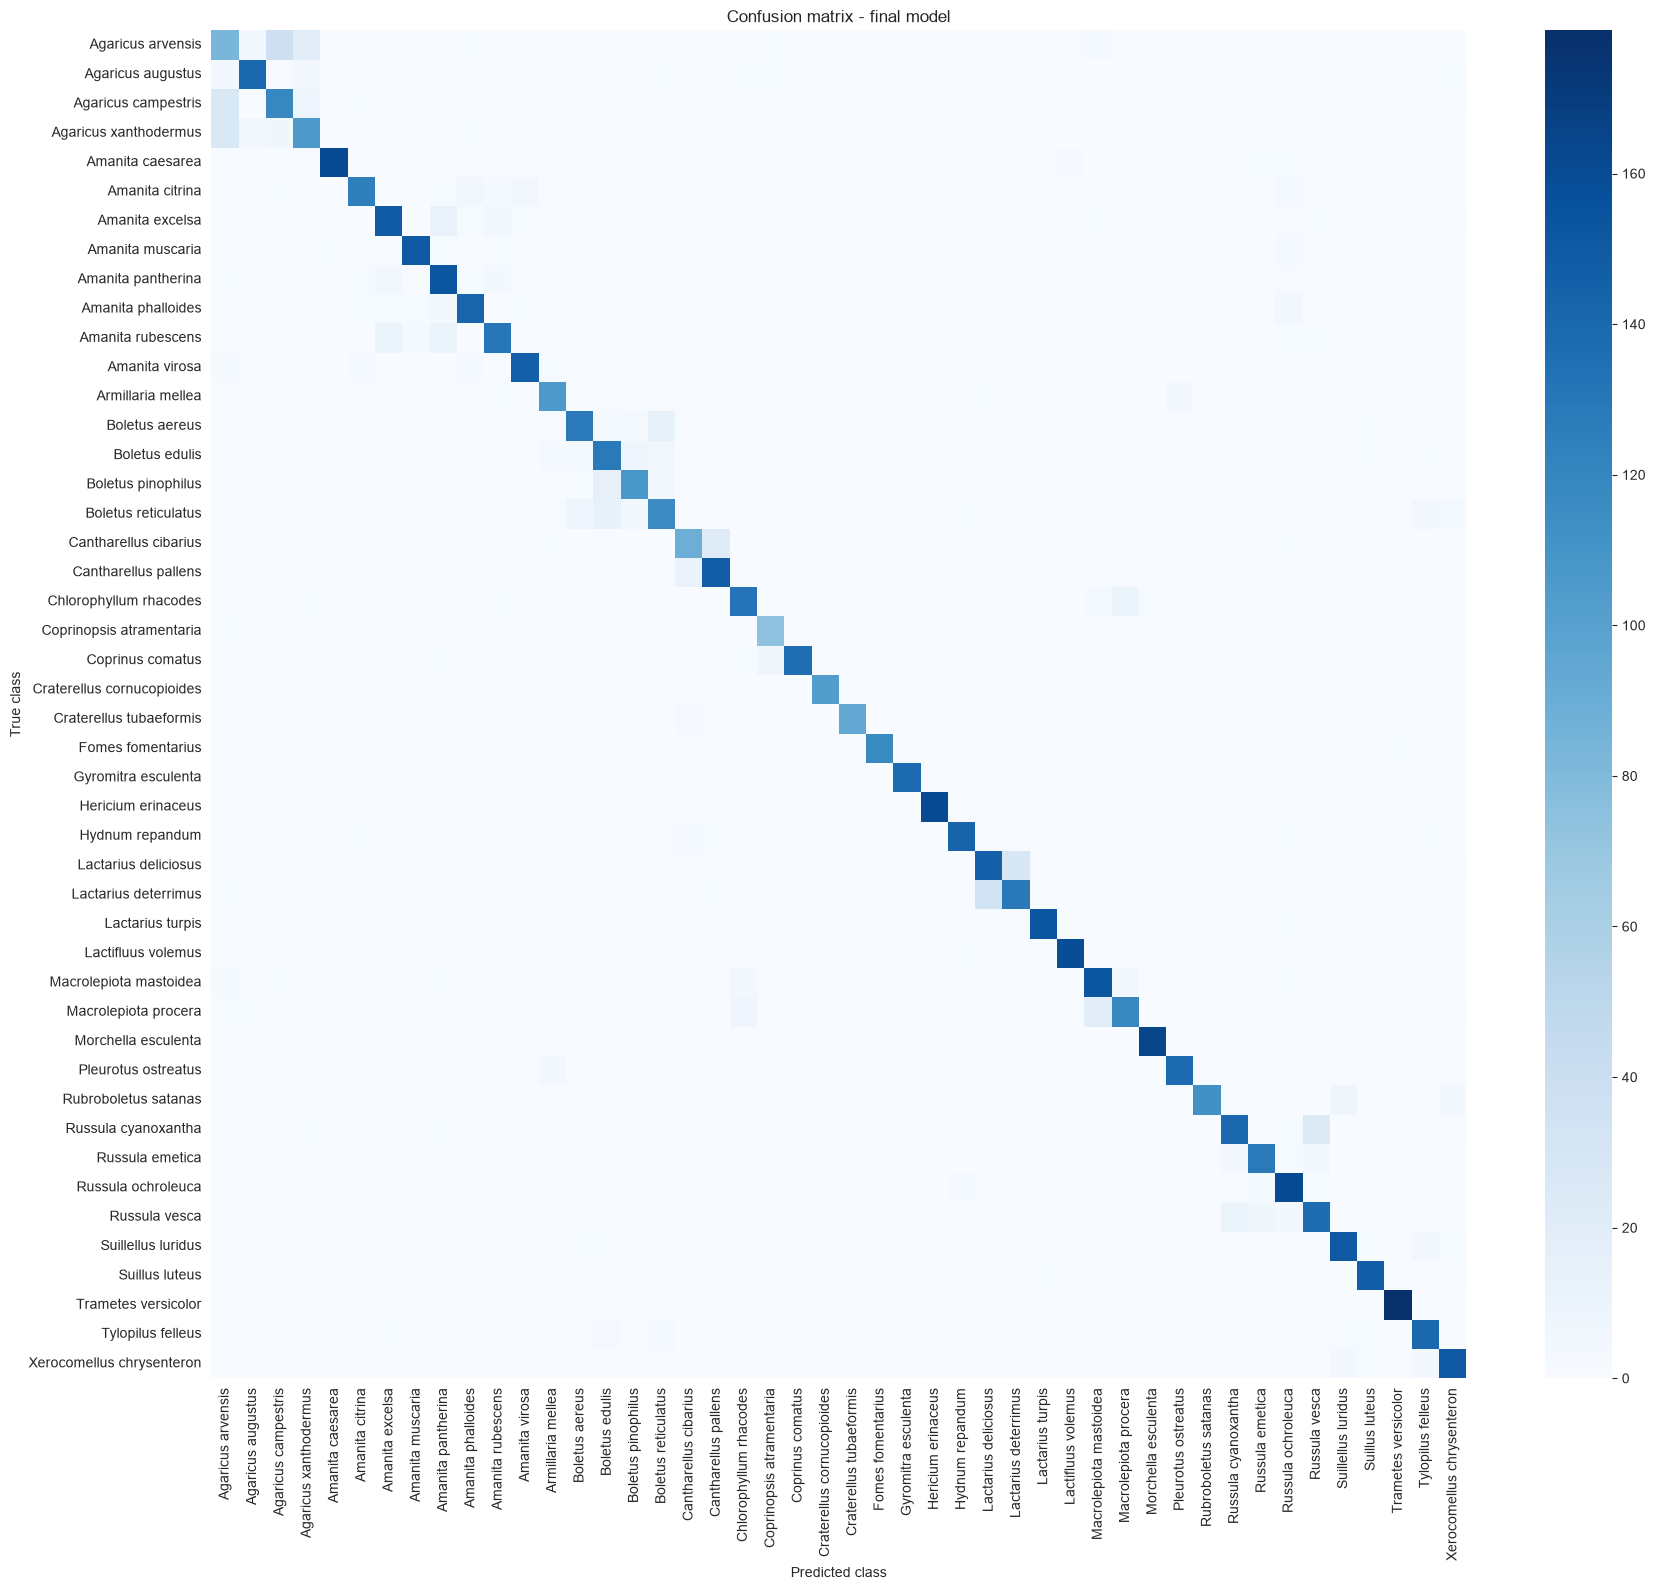

In [24]:
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(18, 16))
sns.heatmap(cm, cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('Confusion matrix - final model')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 10. Per-class accuracy

In [25]:
per_class_accuracy = []

for class_idx, class_name in enumerate(test_dataset.classes):

    class_mask = (all_labels == class_idx)
    class_total = class_mask.sum()
    class_correct = (all_predictions[class_mask] == class_idx).sum()

    accuracy = (class_correct / class_total if class_total > 0 else 0)
    per_class_accuracy.append({
        'Class': class_name,
        'Accuracy': accuracy,
        'Correct': class_correct,
        'Total': class_total
    })


per_class_df = pd.DataFrame(per_class_accuracy)
per_class_df = per_class_df.sort_values(by='Accuracy', ascending=False)

per_class_df

,Class,Accuracy,Correct,Total
34,Morchella esculenta,0.982036,164,167
43,Trametes versicolor,0.978142,179,183
25,Gyromitra esculenta,0.971831,138,142
22,Craterellus cornucopioides,0.971698,103,106
26,Hericium erinaceus,0.969880,161,166
24,Fomes fomentarius,0.959016,117,122
31,Lactifluus volemus,0.957831,159,166
30,Lactarius turpis,0.956250,153,160
42,Suillus luteus,0.954545,147,154
23,Craterellus tubaeformis,0.949495,94,99


### 11. Confidence analysis

In [26]:
correct_mask = (all_labels == all_predictions)
wrong_mask = (all_labels != all_predictions)

correct_confidence = (all_probabilities[correct_mask])
wrong_confidence = (all_probabilities[wrong_mask])

print('=' * 50)
print('CONFIDENCE ANALYSIS')
print('=' * 50)

print(f'Correct predictions : {correct_confidence.mean():.4f}')
print(f'Wrong predictions   : {wrong_confidence.mean():.4f}')

CONFIDENCE ANALYSIS
Correct predictions : 0.9558
Wrong predictions   : 0.7204
